In [106]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Plot styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Data path
DATA_PATH = Path("example_data/building_data_genome_project_2")

## Inertia-focused visual references

To motivate the inertia visuals below:
- **Percentile ribbon + weekday/weekend means** – inspired by [Kaggle: 24h-Ahead Power Prediction and Demand Response](https://www.kaggle.com/code/dophineliu/24h-ahead-power-prediction-and-demand-response), which overlays hundreds of building profiles with average traces.
- **Energy signature / hysteresis** – leverages the classic approach of plotting energy intensity vs. ambient temperature to assess heating/cooling response slopes (see ASHRAE energy signature method and OPSD documentation). These slopes quantify how slowly a building reacts to outdoor changes, i.e., its thermal inertia.

Next sections adapt these ideas specifically to the lodging/residential subset.


In [107]:
# Full data description: https://www.nature.com/articles/s41597-020-00712-x

# Chilled water: Presence of this kind of meter in the building. Yes if affirmative, NaN if negative
chilledwater_df = pd.read_csv(DATA_PATH.joinpath("chilledwater.csv"), sep=',')
chilledwater_cleaned_df = pd.read_csv(DATA_PATH.joinpath("chilledwater_cleaned.csv"), sep=',')

shape = chilledwater_df.shape
print("Chilled water dataframe has", shape[0], "rows and", shape[1], "columns")
chilledwater_cleaned_df.head()

Chilled water dataframe has 17544 rows and 556 columns


,timestamp,Panther_office_Clementine,Panther_lodging_Cora,Panther_education_Teofila,Panther_education_Jerome,Panther_retail_Kristina,Panther_education_Neal,Panther_lodging_Kara,Panther_office_Garth,Panther_office_Lavinia,...,Cockatoo_religion_Diedre,Cockatoo_office_Nola,Cockatoo_assembly_Doyle,Cockatoo_lodging_Kerri,Cockatoo_education_Janet,Cockatoo_education_Minh,Cockatoo_education_June,Cockatoo_education_Lionel,Cockatoo_public_Leah,Cockatoo_health_Ashlie
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.1681,41.0381,1.5330,0.0,93.3358,3.1845,12.9448,0.0,18.3769,206.2924
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.8779,39.6620,1.8534,0.0,89.4310,3.0027,15.3159,0.0,21.7901,199.1167
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.5326,39.4253,1.7707,0.0,85.8087,3.1388,13.8525,0.0,17.6219,208.9164
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.5913,40.4044,1.7458,0.0,90.8272,3.2031,12.4275,0.0,20.6640,202.9993
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0904,41.0916,1.7507,0.0,90.6999,2.9331,12.6853,0.0,16.2412,204.9040


In [108]:
metadata_df = pd.read_csv(DATA_PATH.joinpath("metadata.csv"), sep=',')

shape = metadata_df.shape
print("Metadata dataframe has", shape[0], "rows and", shape[1], "columns")
metadata_df.head()


Metadata dataframe has 1636 rows and 32 columns


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN


In [109]:
weather_df = pd.read_csv(DATA_PATH.joinpath("weather.csv"), sep=',')

shape = weather_df.shape
print("Weather dataframe has", shape[0], "rows and", shape[1], "columns")
weather_df.head()

Weather dataframe has 331166 rows and 10 columns


,timestamp,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Panther,19.4,NaN,19.4,0.0,NaN,NaN,0.0,0.0
1,2016-01-01 01:00:00,Panther,21.1,6.0,21.1,-1.0,NaN,1019.4,0.0,0.0
2,2016-01-01 02:00:00,Panther,21.1,NaN,21.1,0.0,NaN,1018.8,210.0,1.5
3,2016-01-01 03:00:00,Panther,20.6,NaN,20.0,0.0,NaN,1018.1,0.0,0.0
4,2016-01-01 04:00:00,Panther,21.1,NaN,20.6,0.0,NaN,1019.0,290.0,1.5


In [110]:
# Lodging/residential subset
metadata_df['primaryspaceusage'] = metadata_df['primaryspaceusage'].str.strip()
usage_counts = metadata_df['primaryspaceusage'].value_counts(dropna=False).rename_axis('primaryspaceusage').reset_index(name='count')
usage_counts['percent'] = usage_counts['count'] / usage_counts['count'].sum() * 100

lodging_mask = metadata_df['primaryspaceusage'].str.lower() == 'lodging/residential'
lodging_df = metadata_df[lodging_mask].copy()

print(f"Total buildings: {len(metadata_df)}")
print(f"Lodging/residential buildings: {len(lodging_df)}")
print(f"Share of lodging/residential: {len(lodging_df) / len(metadata_df) * 100:.2f}%")

display(usage_counts.head(10))

display(lodging_df[['building_id','site_id','primaryspaceusage','sub_primaryspaceusage','sqm','sqft','yearbuilt','numberoffloors']].head())


Total buildings: 1636
Lodging/residential buildings: 168
Share of lodging/residential: 10.27%


,primaryspaceusage,count,percent
0,Education,617,37.713936
1,Office,307,18.765281
2,Entertainment/public assembly,204,12.469438
3,Lodging/residential,168,10.268949
4,Public services,166,10.146699
5,Other,29,1.772616
6,Healthcare,29,1.772616
7,Parking,24,1.466993
8,NaN,21,1.283619
9,Warehouse/storage,15,0.916870


,building_id,site_id,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,yearbuilt,numberoffloors
0,Panther_lodging_Dean,Panther,Lodging/residential,Residence Hall,508.8,5477.0,1989.0,NaN
1,Panther_lodging_Shelia,Panther,Lodging/residential,Residence Hall,929.0,10000.0,1992.0,NaN
2,Panther_lodging_Ricky,Panther,Lodging/residential,Residence Hall,483.1,5200.0,2016.0,NaN
11,Panther_lodging_Russell,Panther,Lodging/residential,Residence Hall,2594.4,27926.0,1981.0,NaN
13,Panther_lodging_Amos,Panther,Lodging/residential,Residence Hall,1337.2,14393.0,1997.0,NaN


In [111]:
# Sub-category distribution within lodging/residential
sub_counts = lodging_df['sub_primaryspaceusage'].str.strip().value_counts(dropna=False).rename_axis('sub_primaryspaceusage').reset_index(name='count')
sub_counts['percent'] = sub_counts['count'] / sub_counts['count'].sum() * 100
print("Lodging/residential sub-primary usage distribution:")
display(sub_counts)


Lodging/residential sub-primary usage distribution:


,sub_primaryspaceusage,count,percent
0,Dormitory,93,55.357143
1,Residence Hall,44,26.190476
2,Other - Lodging/Residential,10,5.952381
3,Housing,10,5.952381
4,Lodging/residential,4,2.380952
5,Hotel,3,1.785714
6,Residence Hall/Dormitory,3,1.785714
7,Multifamily Housing,1,0.595238


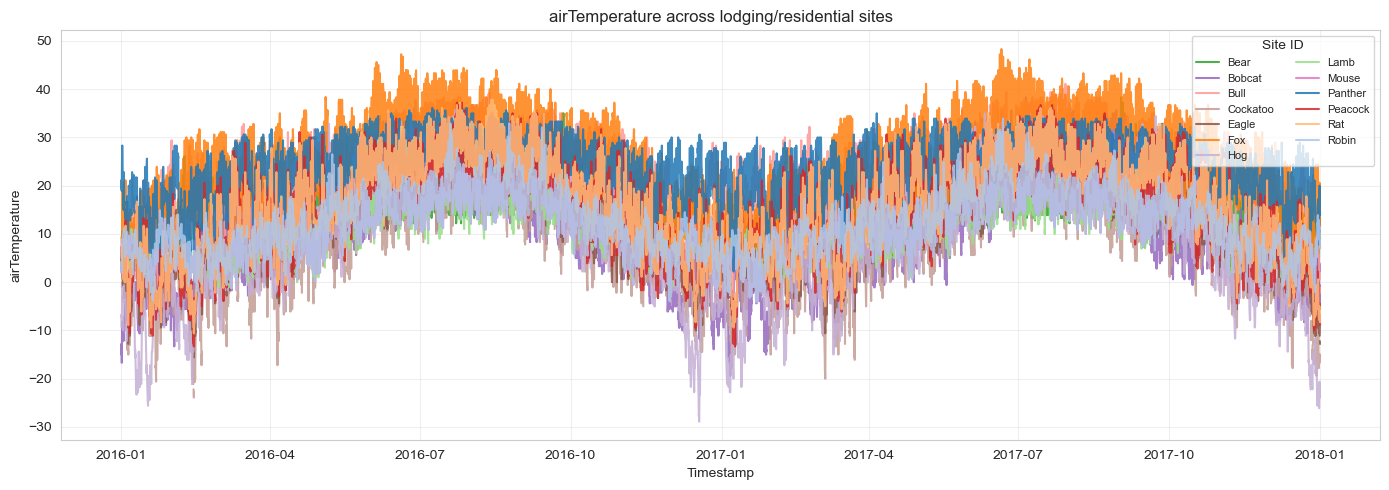

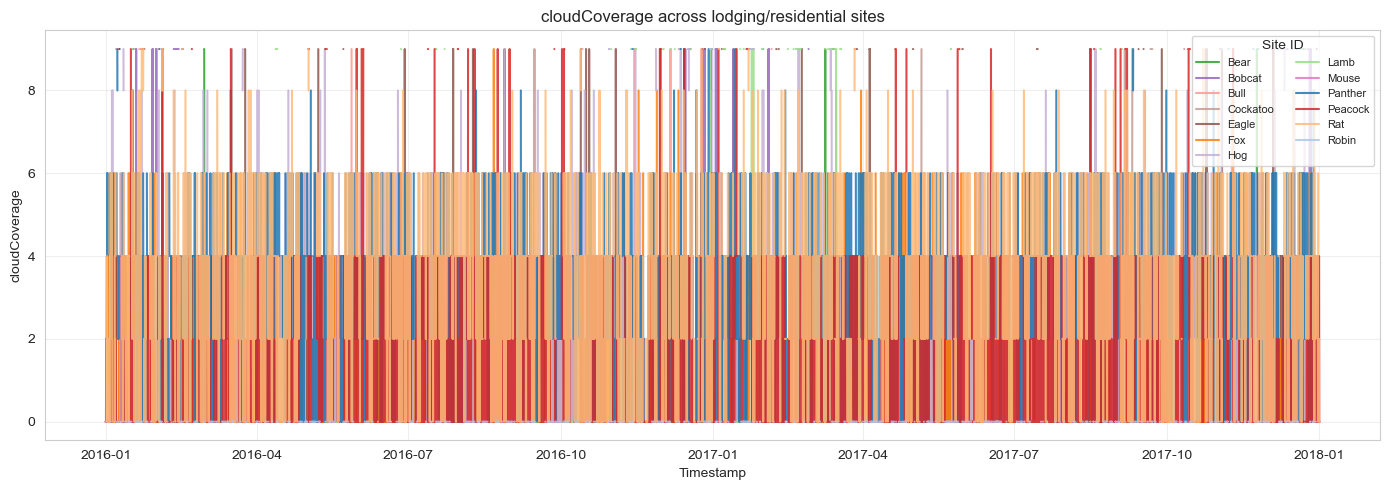

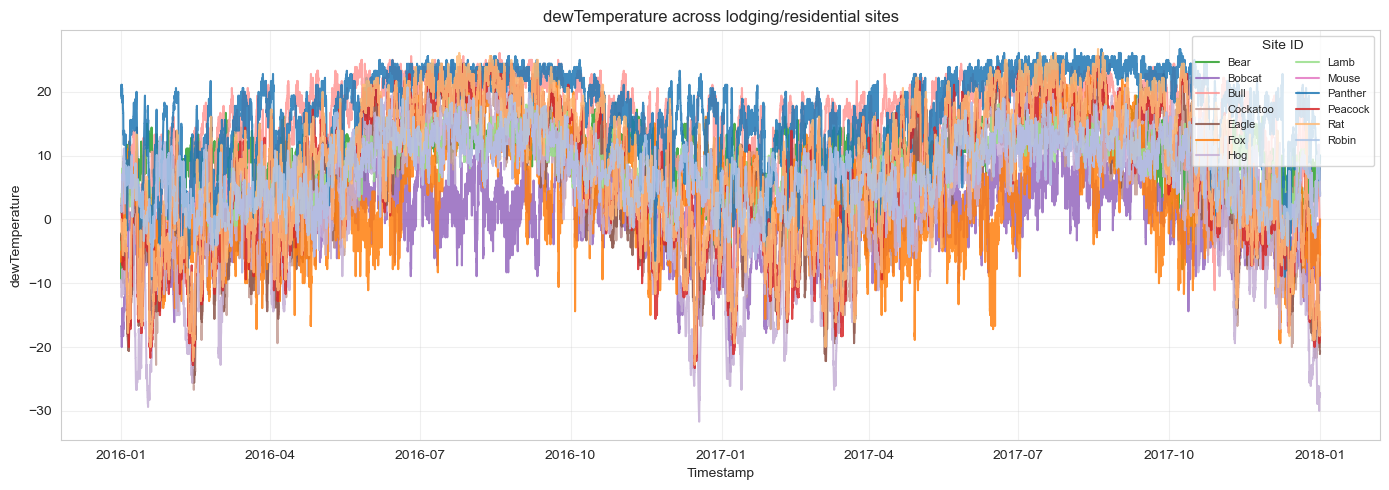

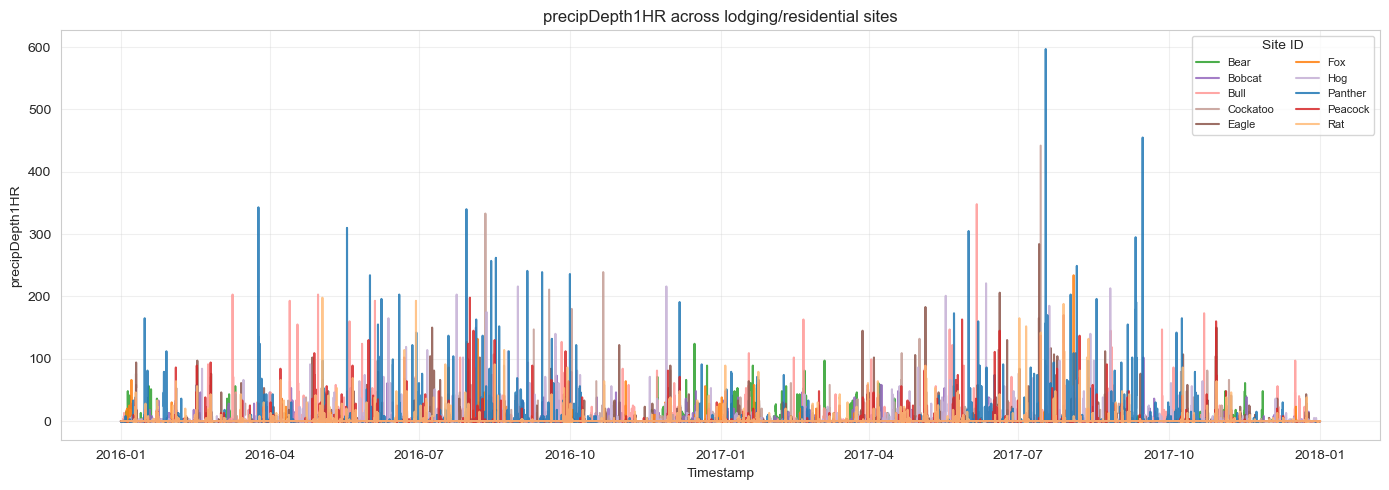

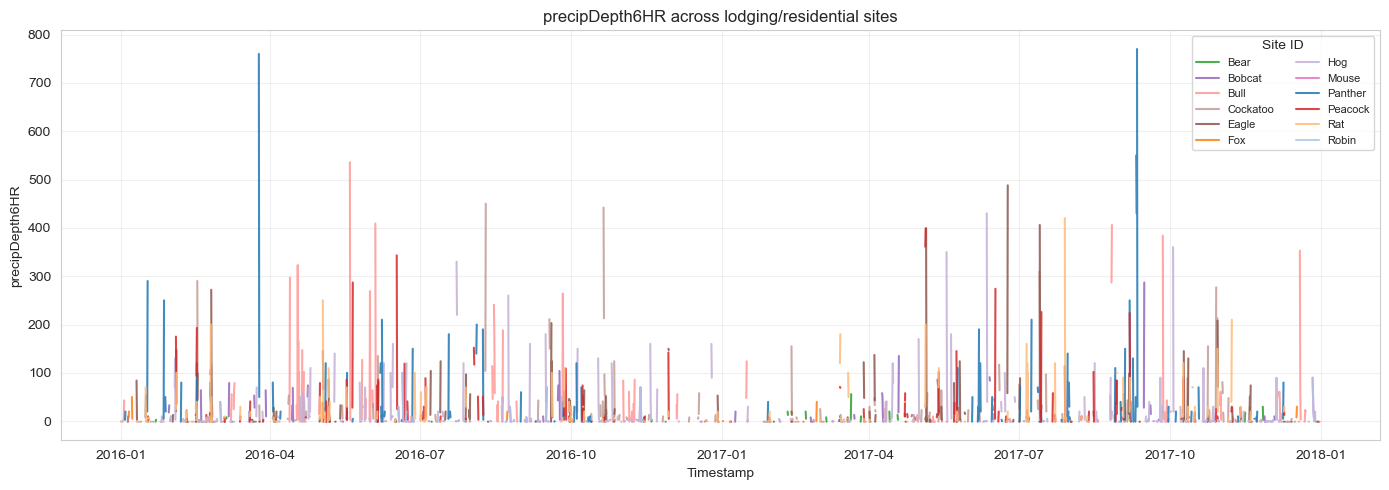

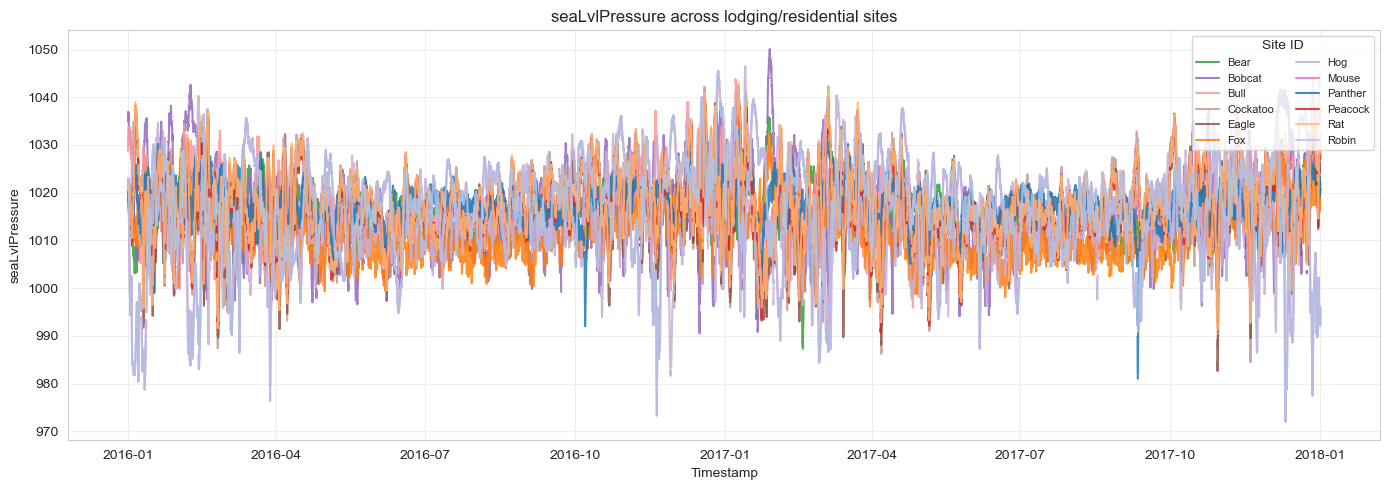

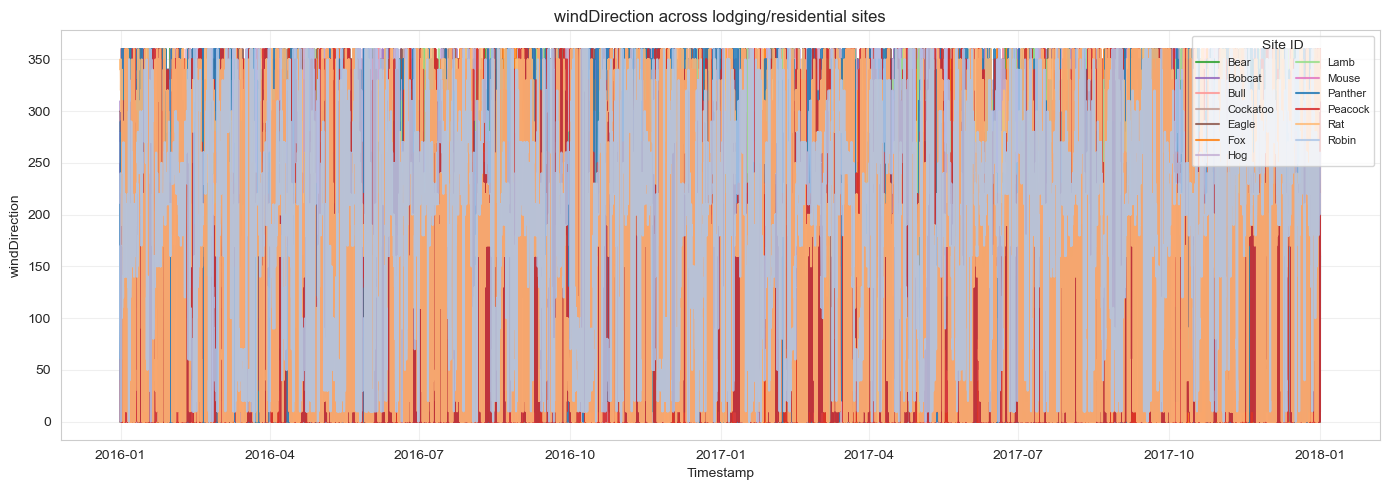

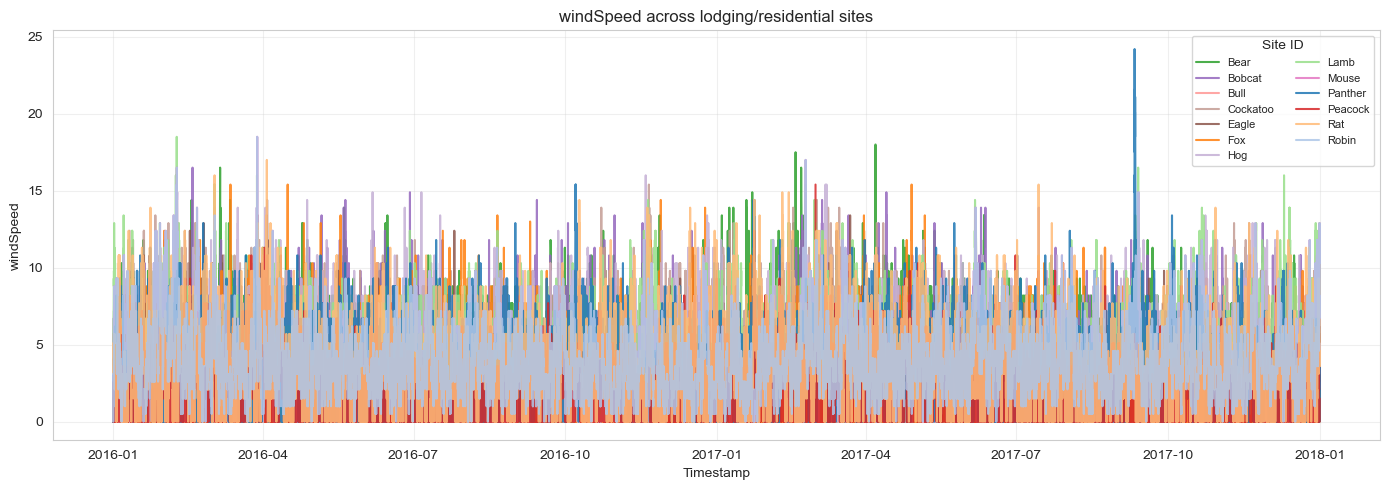

In [112]:
# Weather trends for lodging/residential sites
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
residential_sites = metadata_df.loc[metadata_df['primaryspaceusage'].str.lower() == 'lodging/residential', 'site_id'].unique()
res_weather = weather_df[weather_df['site_id'].isin(residential_sites)].copy()

weather_columns = [col for col in res_weather.columns if col not in {'timestamp', 'site_id'}]

site_palette = sns.color_palette('tab20', n_colors=len(residential_sites))
site_colors = dict(zip(residential_sites, site_palette))

for metric in weather_columns:
    pivot = res_weather.pivot_table(index='timestamp', columns='site_id', values=metric)

    plt.figure(figsize=(14, 5))
    for site_id in pivot.columns:
        plt.plot(pivot.index, pivot[site_id], label=site_id, color=site_colors.get(site_id), alpha=0.85)

    plt.title(f"{metric} across lodging/residential sites")
    plt.xlabel('Timestamp')
    plt.ylabel(metric)
    plt.legend(title='Site ID', loc='upper right', ncol=2, fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [113]:
# Electricity (kWh) per square foot for lodging/residential buildings
from matplotlib.ticker import FuncFormatter

# Load electricity data (cleaned)
electricity_path = DATA_PATH / "electricity_cleaned.csv"
electricity_df = pd.read_csv(electricity_path)

building_cols = [c for c in electricity_df.columns if c != 'timestamp']
sqft_map = metadata_df.set_index('building_id')['sqft']
areas = sqft_map.reindex(building_cols).astype(float)

electricity_per_sqft = electricity_df[building_cols].astype(float).div(areas, axis=1)
electricity_per_sqft.insert(0, 'timestamp', electricity_df['timestamp'])

lodging_buildings = metadata_df.loc[metadata_df['primaryspaceusage'].str.lower() == 'lodging/residential', 'building_id']
res_cols = [c for c in lodging_buildings if c in electricity_per_sqft.columns]
res_power = electricity_per_sqft[['timestamp'] + res_cols].copy()

print(f"Residential buildings with electricity data: {len(res_cols)}")


Residential buildings with electricity data: 149


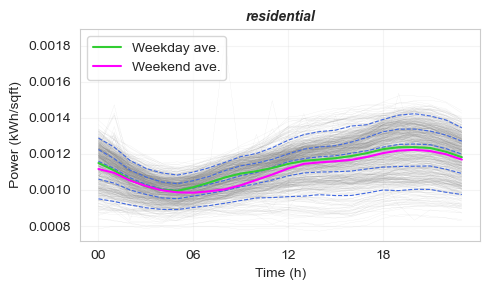

In [114]:
def plot_daily_profile(df, type_label="residential"):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df['timestamp'].dt.date
    df['time'] = df['timestamp'].dt.hour
    df['weekday'] = df['timestamp'].dt.weekday

    value_cols = df.columns.difference(['timestamp', 'date', 'time', 'weekday'])
    df['average'] = df[value_cols].mean(axis=1)

    df_avg = df[['date', 'time', 'weekday', 'average']]
    df_pivot = pd.pivot_table(df_avg, index=['date', 'weekday'], columns='time', values='average').T.sort_index()

    df_weekday = df[df['weekday'] <= 4]
    df_weekend = df[df['weekday'] > 4]

    df_pivot_weekday = pd.pivot_table(df_weekday[['date', 'time', 'weekday', 'average']], index=['date', 'weekday'], columns='time', values='average').T.sort_index()
    df_pivot_weekend = pd.pivot_table(df_weekend[['date', 'time', 'weekday', 'average']], index=['date', 'weekday'], columns='time', values='average').T.sort_index()

    df_weekday_mean = df_pivot_weekday.mean(axis=1).to_frame('Weekday ave.')
    df_weekend_mean = df_pivot_weekend.mean(axis=1).to_frame('Weekend ave.')

    percentiles = pd.concat([
        df_pivot.quantile(q=0.95, axis=1),
        df_pivot.quantile(q=0.75, axis=1),
        df_pivot.quantile(q=0.50, axis=1),
        df_pivot.quantile(q=0.25, axis=1),
        df_pivot.quantile(q=0.05, axis=1),
    ], axis=1)
    percentiles.columns = ['q95', 'q75', 'median', 'q25', 'q05']

    hours = df_pivot.index
    xticks = [0, 6, 12, 18]

    fig, ax = plt.subplots(figsize=(5, 3))

    if not df_pivot_weekday.empty:
        for col in df_pivot_weekday.columns:
            ax.plot(hours, df_pivot_weekday[col], color='grey', linewidth=0.05, alpha=0.6)
    if not df_pivot_weekend.empty:
        for col in df_pivot_weekend.columns:
            ax.plot(hours, df_pivot_weekend[col], color='grey', linewidth=0.05, alpha=0.6)

    for col in ['q95', 'q75', 'median', 'q25', 'q05']:
        ax.plot(hours, percentiles[col], color='royalblue', linewidth=0.8, linestyle='--')

    df_weekday_mean.plot(ax=ax, color='limegreen', linewidth=1.5)
    df_weekend_mean.plot(ax=ax, color='magenta', linewidth=1.5)

    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{h:02d}" for h in xticks])
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Power (kWh/sqft)')
    ax.set_title(type_label.lower(), fontsize=10, fontstyle='italic', fontweight='bold')
    ax.legend(loc='upper left', frameon=True)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_daily_profile(res_power, type_label='Residential')


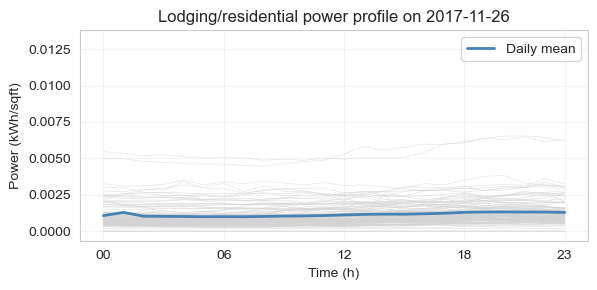

In [115]:
# Detailed view for 26 November 2017
random_day = pd.Timestamp('2017-11-26').date()
res_power_day = res_power.copy()
res_power_day['timestamp'] = pd.to_datetime(res_power_day['timestamp'])
res_power_day['date'] = res_power_day['timestamp'].dt.date
res_power_day['hour'] = res_power_day['timestamp'].dt.hour

sample_day = res_power_day[res_power_day['date'] == random_day]

if sample_day.empty:
    print(f"No data for {random_day}")
else:
    hours = sample_day['hour'].values
    values = sample_day[res_cols].astype(float)

    fig, ax = plt.subplots(figsize=(6, 3))
    for col in values.columns:
        ax.plot(hours, values[col].values, color='lightgrey', linewidth=0.4, alpha=0.7)

    mean_profile = values.mean(axis=1)
    ax.plot(hours, mean_profile, color='steelblue', linewidth=2, label='Daily mean')

    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['00', '06', '12', '18', '23'])
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Power (kWh/sqft)')
    ax.set_title(f'Lodging/residential power profile on {random_day}')
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


In [116]:
# Utility helpers to build per-building datasets
MEASUREMENT_FILES = {
    'electricity_kwh': DATA_PATH / 'electricity_cleaned.csv',
    'hotwater': DATA_PATH / 'hotwater_cleaned.csv',
    'chilledwater': DATA_PATH / 'chilledwater_cleaned.csv',
    'steam': DATA_PATH / 'steam_cleaned.csv',
    'water': DATA_PATH / 'water_cleaned.csv',
    'irrigation': DATA_PATH / 'irrigation_cleaned.csv',
    'solar': DATA_PATH / 'solar_cleaned.csv',
    'gas': DATA_PATH / 'gas_cleaned.csv',
}

_measurement_cache = {}
_per_sqft_cache = {}

def load_measurement(name: str) -> pd.DataFrame:
    if name not in _measurement_cache:
        path = MEASUREMENT_FILES[name]
        df = pd.read_csv(path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        _measurement_cache[name] = df
    return _measurement_cache[name]

def load_measurement_per_sqft(name: str) -> pd.DataFrame:
    if name not in _per_sqft_cache:
        df = load_measurement(name)
        building_cols = [c for c in df.columns if c != 'timestamp']
        sqft_map = metadata_df.set_index('building_id')['sqft']
        areas = sqft_map.reindex(building_cols).astype(float)
        intensity = df[building_cols].astype(float).div(areas, axis=1)
        intensity.insert(0, 'timestamp', df['timestamp'])
        _per_sqft_cache[name] = intensity
    return _per_sqft_cache[name]


def build_building_dataframe(building_id: str, include_weather: bool = True, include_metadata: bool = True) -> pd.DataFrame:
    merged = None
    available_sources = []

    for feature, path in MEASUREMENT_FILES.items():
        df = load_measurement(feature)
        if building_id not in df.columns:
            continue
        subset = df[['timestamp', building_id]].rename(columns={building_id: feature})
        available_sources.append(feature)
        merged = subset if merged is None else merged.merge(subset, on='timestamp', how='outer')

    if merged is None:
        raise ValueError(f"Building {building_id} not found in any measurement file")

    if include_weather:
        site_id = metadata_df.loc[metadata_df['building_id'] == building_id, 'site_id'].iloc[0]
        weather_subset = weather_df[weather_df['site_id'] == site_id].drop(columns=['site_id']).copy()
        weather_subset = weather_subset.rename(columns=lambda c: f"weather_{c}" if c != 'timestamp' else c)
        merged = merged.merge(weather_subset, on='timestamp', how='outer')

    if include_metadata:
        meta_row = metadata_df[metadata_df['building_id'] == building_id].iloc[0].to_dict()
        for key, value in meta_row.items():
            merged[key] = value

    merged = merged.sort_values('timestamp').reset_index(drop=True)
    merged.attrs['sources'] = available_sources
    return merged

def summarize_building_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    measurements = [c for c in df.columns if c.startswith(('electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'weather_'))]
    summary = pd.DataFrame({
        'non_null_count': df[measurements].notna().sum(),
        'non_null_fraction': df[measurements].notna().sum() / len(df)
    })
    summary['unit'] = summary.index.map(lambda c: 'kWh/sqft' if 'electricity' in c else '')
    return summary.sort_values('non_null_fraction', ascending=False)



### Energy signature as a thermal inertia proxy
This scatter + smoothed profile shows how residential electricity intensity changes with outdoor temperature. The slope/curvature reflects how quickly buildings respond to thermal forcing (flatter = higher inertia).


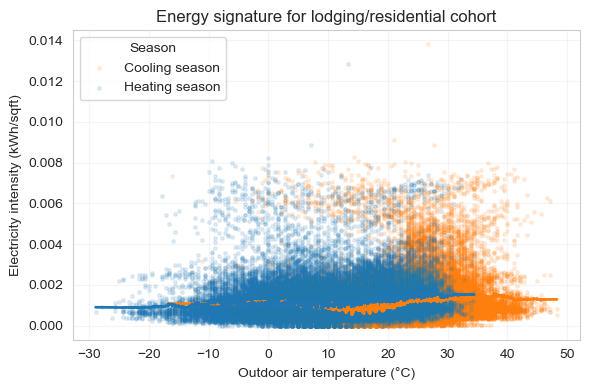

Cooling season: slope 0.00002 kWh/sqft per °C, intercept 0.00072
Heating season: slope 0.00001 kWh/sqft per °C, intercept 0.00104


In [117]:
# Energy signature / thermal inertia scatter
res_power_long = res_power.copy()
res_power_long['timestamp'] = pd.to_datetime(res_power_long['timestamp'])
res_long = res_power_long.melt(id_vars='timestamp', var_name='building_id', value_name='power_kwh_sqft').dropna(subset=['power_kwh_sqft'])
res_long = res_long.merge(metadata_df[['building_id', 'site_id']], on='building_id', how='left')
res_long = res_long.merge(weather_df[['timestamp', 'site_id', 'airTemperature']], on=['timestamp', 'site_id'], how='left')
res_long = res_long.dropna(subset=['airTemperature'])
res_long['season'] = np.where(res_long['timestamp'].dt.month.isin([11,12,1,2,3]), 'Heating season', 'Cooling season')

sampled = res_long.sample(min(120000, len(res_long)), random_state=42)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'Heating season': 'tab:blue', 'Cooling season': 'tab:orange'}
for season, df_season in sampled.groupby('season'):
    ax.scatter(df_season['airTemperature'], df_season['power_kwh_sqft'], color=colors[season], alpha=0.12, s=6, label=season)
    df_sorted = df_season[['airTemperature', 'power_kwh_sqft']].sort_values('airTemperature').reset_index(drop=True)
    window = max(150, len(df_sorted) // 200)
    df_sorted['smooth'] = df_sorted['power_kwh_sqft'].rolling(window=window, min_periods=max(50, window // 2), center=True).mean()
    ax.plot(df_sorted['airTemperature'], df_sorted['smooth'], color=colors[season], linewidth=2)

ax.set_xlabel('Outdoor air temperature (°C)')
ax.set_ylabel('Electricity intensity (kWh/sqft)')
ax.set_title('Energy signature for lodging/residential cohort')
ax.legend(title='Season')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Regression slopes by season
for season, df_season in res_long.groupby('season'):
    coefs = np.polyfit(df_season['airTemperature'], df_season['power_kwh_sqft'], 1)
    print(f"{season}: slope {coefs[0]:.5f} kWh/sqft per °C, intercept {coefs[1]:.5f}")


### Load persistence and lag diagnostics
Autocorrelation and lag scatter plots quantify short-term inertia: strong correlation between consecutive hours means loads change slowly, while weaker correlation indicates fast-reacting buildings.


### Temperature step-response
This experiment looks for sudden ≥3 °C drops and measures how much electricity rises in the following hours. A sluggish, low-amplitude response hints at higher thermal inertia.


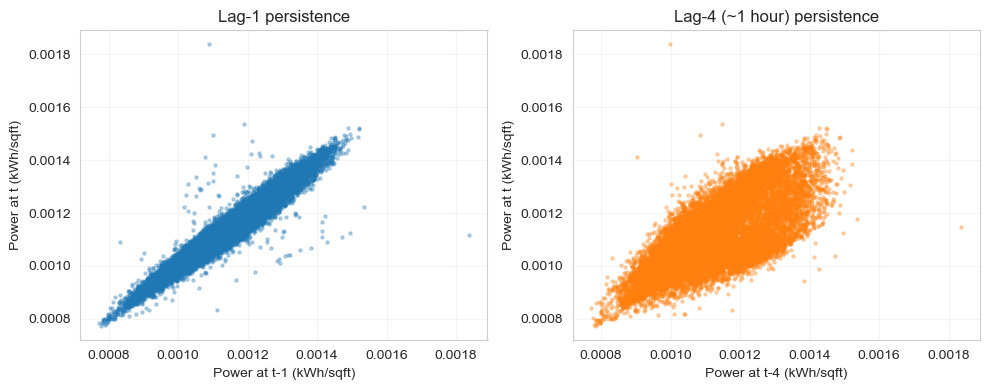

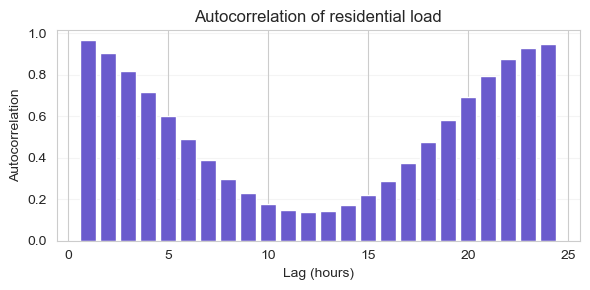

Correlation coefficients:
Lag 1: 0.967, Lag 4: 0.715, Lag 12: 0.136


In [118]:
# Load persistence & lag diagnostics
res_profile = res_power.copy()
res_profile['timestamp'] = pd.to_datetime(res_profile['timestamp'])
res_profile['power_mean'] = res_profile[res_cols].mean(axis=1)
res_profile = res_profile[['timestamp', 'power_mean']].dropna()
res_profile['power_lag1'] = res_profile['power_mean'].shift(1)
res_profile['power_lag4'] = res_profile['power_mean'].shift(4)
res_profile['delta'] = res_profile['power_mean'].diff()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(res_profile['power_lag1'], res_profile['power_mean'], alpha=0.3, s=5)
axes[0].set_xlabel('Power at t-1 (kWh/sqft)')
axes[0].set_ylabel('Power at t (kWh/sqft)')
axes[0].set_title('Lag-1 persistence')
axes[0].grid(alpha=0.2)

axes[1].scatter(res_profile['power_lag4'], res_profile['power_mean'], alpha=0.3, s=5, color='tab:orange')
axes[1].set_xlabel('Power at t-4 (kWh/sqft)')
axes[1].set_ylabel('Power at t (kWh/sqft)')
axes[1].set_title('Lag-4 (~1 hour) persistence')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Autocorrelation up to 24 lags
lags = range(1, 25)
autocorr = [res_profile['power_mean'].autocorr(lag=l) for l in lags]
plt.figure(figsize=(6, 3))
plt.bar(lags, autocorr, color='slateblue')
plt.xlabel('Lag (hours)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of residential load')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print('Correlation coefficients:')
print(f"Lag 1: {autocorr[0]:.3f}, Lag 4: {autocorr[3]:.3f}, Lag 12: {autocorr[11]:.3f}")


### Diurnal persistence heatmap
Average absolute changes between consecutive hours highlight when loads are most stable (dark) vs. volatile (bright). Weekday/weekend comparison shows operational inertia differences.


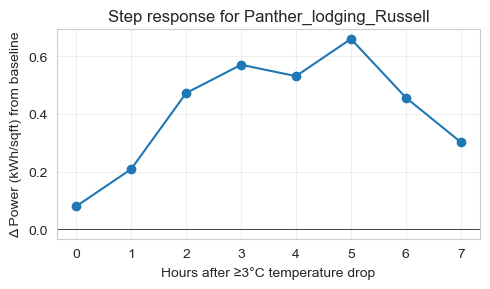

In [119]:
# Optional: temperature step-response for a representative building
def plot_step_response(building_id: str, temp_drop_threshold: float = -3.0, horizon: int = 8):
    df = build_building_dataframe(building_id)
    cols_needed = ['timestamp', 'electricity_kwh', 'weather_airTemperature']
    if not all(col in df.columns for col in cols_needed):
        print(f"Missing columns for {building_id}; skipping")
        return
    data = df[cols_needed].dropna().sort_values('timestamp').reset_index(drop=True)
    data['temp_delta'] = data['weather_airTemperature'].diff()
    responses = []
    for idx in range(1, len(data) - horizon):
        if data.loc[idx, 'temp_delta'] <= temp_drop_threshold:
            baseline = data.loc[idx - 1, 'electricity_kwh']
            window = data.loc[idx:idx + horizon - 1, 'electricity_kwh'].values - baseline
            responses.append(window)
    if not responses:
        print(f"No large temperature drops detected for {building_id}")
        return
    mean_response = np.mean(responses, axis=0)
    hours = np.arange(horizon)
    plt.figure(figsize=(5, 3))
    plt.plot(hours, mean_response, marker='o')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.xlabel('Hours after ≥3°C temperature drop')
    plt.ylabel('Δ Power (kWh/sqft) from baseline')
    plt.title(f'Step response for {building_id}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_step_response(example_building)


## Load vs. weather overlays
To see load and weather evolving together, we average electricity and water intensities across all residential buildings and align them with the mean outdoor temperature for the same timestamps. This reveals whether peaks/valleys in consumption co-move with weather forcing over the course of the year.


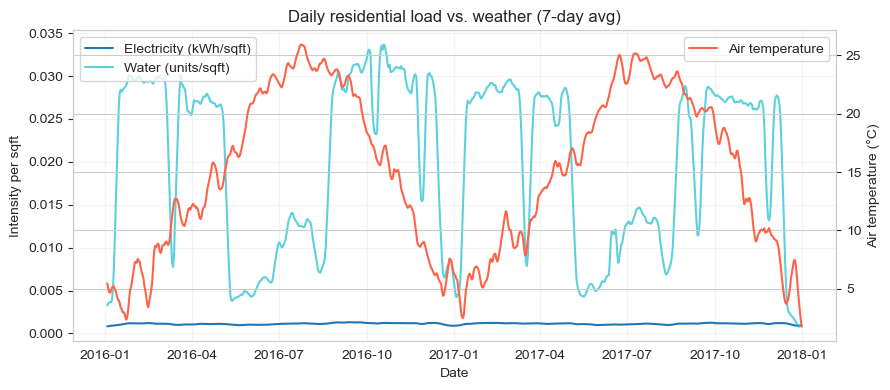

In [120]:
def aggregate_mean_series(df: pd.DataFrame, building_ids, label: str) -> pd.DataFrame:
    cols = [c for c in building_ids if c in df.columns]
    if not cols:
        return pd.DataFrame(columns=['timestamp', label])
    data = df[['timestamp'] + cols].copy()
    data['timestamp'] = pd.to_datetime(data['timestamp'])
    data[label] = data[cols].mean(axis=1)
    return data[['timestamp', label]]

electricity_intensity = load_measurement_per_sqft('electricity_kwh')
water_intensity = load_measurement_per_sqft('water')
elec_series = aggregate_mean_series(electricity_intensity, lodging_buildings, 'electricity_kwh_sqft')
water_series = aggregate_mean_series(water_intensity, lodging_buildings, 'water_gal_sqft')

weather_res = weather_df[weather_df['site_id'].isin(residential_sites)].copy()
weather_res['timestamp'] = pd.to_datetime(weather_res['timestamp'])
weather_mean = weather_res.groupby('timestamp')[['airTemperature', 'dewTemperature']].mean().reset_index()

overlay = elec_series.merge(water_series, on='timestamp', how='outer')
overlay = overlay.merge(weather_mean, on='timestamp', how='left')
overlay = overlay.set_index('timestamp').sort_index().resample('D').mean().rolling(window=7, min_periods=3).mean()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(overlay.index, overlay['electricity_kwh_sqft'], label='Electricity (kWh/sqft)', color='tab:blue')
ax1.plot(overlay.index, overlay['water_gal_sqft'], label='Water (units/sqft)', color='tab:cyan', alpha=0.7)
ax1.set_ylabel('Intensity per sqft')
ax1.set_xlabel('Date')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(overlay.index, overlay['airTemperature'], color='tomato', label='Air temperature')
ax2.set_ylabel('Air temperature (°C)')
ax2.legend(loc='upper right')
plt.title('Daily residential load vs. weather (7-day avg)')
plt.tight_layout()
plt.show()



### Yearly average profile per building
Below, each grey line is a building’s month-by-month average electricity intensity (normalized), overlaid with the cohort mean and the corresponding average outdoor temperature.


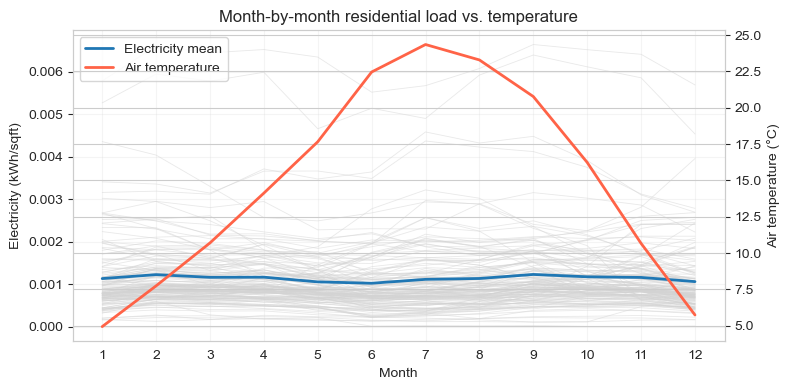

In [121]:
monthly_power = res_long.copy()
monthly_power['month'] = monthly_power['timestamp'].dt.month
monthly_avg = monthly_power.groupby(['building_id', 'month'])['power_kwh_sqft'].mean().reset_index()
monthly_pivot = monthly_avg.pivot(index='month', columns='building_id', values='power_kwh_sqft')

fig, ax1 = plt.subplots(figsize=(8, 4))
for col in monthly_pivot.columns:
    ax1.plot(monthly_pivot.index, monthly_pivot[col], color='lightgrey', linewidth=0.6, alpha=0.5)

cohort_mean = monthly_pivot.mean(axis=1)
ax1.plot(monthly_pivot.index, cohort_mean, color='tab:blue', linewidth=2, label='Electricity mean')
ax1.set_xlabel('Month')
ax1.set_ylabel('Electricity (kWh/sqft)')
ax1.set_xticks(range(1, 13))
ax1.grid(alpha=0.2)

monthly_temp = weather_res.copy()
monthly_temp['month'] = monthly_temp['timestamp'].dt.month
monthly_temp_mean = monthly_temp.groupby('month')['airTemperature'].mean()
ax2 = ax1.twinx()
ax2.plot(monthly_temp_mean.index, monthly_temp_mean.values, color='tomato', linewidth=2, label='Air temperature')
ax2.set_ylabel('Air temperature (°C)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Month-by-month residential load vs. temperature')
plt.tight_layout()
plt.show()


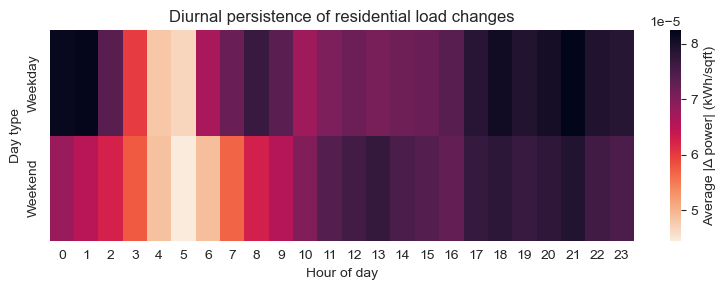

In [122]:
# Diurnal persistence heatmap (average |Δpower| between consecutive hours)
delta = res_power[res_cols].diff().abs()
delta.insert(0, 'timestamp', pd.to_datetime(res_power['timestamp']))
delta['hour'] = delta['timestamp'].dt.hour
delta['weekday_type'] = np.where(delta['timestamp'].dt.weekday <= 4, 'Weekday', 'Weekend')
long_delta = delta.melt(id_vars=['timestamp', 'hour', 'weekday_type'], value_name='abs_change').dropna(subset=['abs_change'])
heat = long_delta.groupby(['weekday_type', 'hour'])['abs_change'].mean().reset_index()
heat_pivot = heat.pivot(index='weekday_type', columns='hour', values='abs_change')

plt.figure(figsize=(8, 3))
sns.heatmap(heat_pivot, cmap='rocket_r', cbar_kws={'label': 'Average |Δ power| (kWh/sqft)'})
plt.xlabel('Hour of day')
plt.ylabel('Day type')
plt.title('Diurnal persistence of residential load changes')
plt.tight_layout()
plt.show()


In [123]:
# Example: build combined dataframe for one residential building
example_building = res_cols[0]
building_df = build_building_dataframe(example_building)
print(f"Combined dataframe for {example_building} -> {building_df.shape[0]} rows, {building_df.shape[1]} columns")
print("Sources joined:", building_df.attrs.get('sources'))

print(f"Dataframe contains columns: {building_df.columns.tolist()}")

display(building_df.head())


Combined dataframe for Panther_lodging_Russell -> 17544 rows, 42 columns
Sources joined: ['electricity_kwh', 'water']
Dataframe contains columns: ['timestamp', 'electricity_kwh', 'water', 'weather_airTemperature', 'weather_cloudCoverage', 'weather_dewTemperature', 'weather_precipDepth1HR', 'weather_precipDepth6HR', 'weather_seaLvlPressure', 'weather_windDirection', 'weather_windSpeed', 'building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']


,timestamp,electricity_kwh,water,weather_airTemperature,weather_cloudCoverage,weather_dewTemperature,weather_precipDepth1HR,weather_precipDepth6HR,weather_seaLvlPressure,weather_windDirection,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,2016-01-01 00:00:00,NaN,Yes,19.4,NaN,19.4,0.0,NaN,NaN,0.0,...,1981.0,NaN,NaN,NaN,NaN,58,NaN,NaN,NaN,NaN
1,2016-01-01 01:00:00,NaN,Yes,21.1,6.0,21.1,-1.0,NaN,1019.4,0.0,...,1981.0,NaN,NaN,NaN,NaN,58,NaN,NaN,NaN,NaN
2,2016-01-01 02:00:00,NaN,Yes,21.1,NaN,21.1,0.0,NaN,1018.8,210.0,...,1981.0,NaN,NaN,NaN,NaN,58,NaN,NaN,NaN,NaN
3,2016-01-01 03:00:00,NaN,Yes,20.6,NaN,20.0,0.0,NaN,1018.1,0.0,...,1981.0,NaN,NaN,NaN,NaN,58,NaN,NaN,NaN,NaN
4,2016-01-01 04:00:00,NaN,Yes,21.1,NaN,20.6,0.0,NaN,1019.0,290.0,...,1981.0,NaN,NaN,NaN,NaN,58,NaN,NaN,NaN,NaN


In [124]:
summary = summarize_building_dataframe(building_df)
display(summary)

,non_null_count,non_null_fraction,unit
water,17544,1.000000,
electricity,17544,1.000000,kWh/sqft
weather_windSpeed,17544,1.000000,
weather_airTemperature,17541,0.999829,
weather_dewTemperature,17541,0.999829,
weather_precipDepth1HR,17535,0.999487,
weather_seaLvlPressure,17221,0.981589,
weather_windDirection,17045,0.971557,
electricity_kwh,14157,0.806943,kWh/sqft
weather_cloudCoverage,10002,0.570109,
